# Battery Health Prediction

Machine Learning for Data Engineers - Project

Predicting the State of Health (SOH) of batteries used in renewable energy systems from their cycling data.

We start with simple models (Linear Regression, Random Forest) and then build a Neural Network.

## 1. Importing the libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
%matplotlib inline

## 2. Loading and exploring the dataset

In [39]:
df = pd.read_csv("battery_data.csv")
df.head()

,Battery_ID,Cycle,Capacity_Ah,SOH,Internal_Resistance_Ohm,Temperature_C,Voltage_Max_V,Voltage_Min_V,Charge_Time_s,Discharge_Time_s,Ambient_Temp_C,RUL
0,1,1,1.9440,99.425,0.04709,32.87,4.1912,3.2083,3633.7,3000.7,32.88,552
1,1,2,1.9636,100.342,0.04660,33.35,4.1899,3.2079,3603.2,2988.8,32.88,551
2,1,3,1.9522,99.565,0.04735,32.41,4.1957,3.2040,3622.4,3010.8,32.88,550
3,1,4,1.9644,99.955,0.04715,32.32,4.1908,3.2044,3655.6,2987.8,32.88,549
4,1,5,1.9386,99.392,0.04826,33.84,4.2041,3.1911,3622.3,2995.2,32.88,548


In [40]:
df.shape

(34607, 12)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34607 entries, 0 to 34606
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Battery_ID               34607 non-null  int64  
 1   Cycle                    34607 non-null  int64  
 2   Capacity_Ah              34607 non-null  float64
 3   SOH                      34607 non-null  float64
 4   Internal_Resistance_Ohm  34607 non-null  float64
 5   Temperature_C            34607 non-null  float64
 6   Voltage_Max_V            34607 non-null  float64
 7   Voltage_Min_V            34607 non-null  float64
 8   Charge_Time_s            34607 non-null  float64
 9   Discharge_Time_s         34607 non-null  float64
 10  Ambient_Temp_C           34607 non-null  float64
 11  RUL                      34607 non-null  int64  
dtypes: float64(9), int64(3)
memory usage: 3.2 MB


In [42]:
df.describe()

,Battery_ID,Cycle,Capacity_Ah,SOH,Internal_Resistance_Ohm,Temperature_C,Voltage_Max_V,Voltage_Min_V,Charge_Time_s,Discharge_Time_s,Ambient_Temp_C,RUL
count,34607.000000,34607.000000,34607.000000,34607.000000,34607.000000,34607.000000,34607.000000,34607.000000,34607.000000,34607.000000,34607.000000,34607.000000
mean,20.596873,449.786315,1.596214,83.315863,0.075317,30.995402,4.124923,3.074867,4321.056523,2474.424784,26.992591,448.786315
std,11.534190,275.040606,0.197555,10.120367,0.013398,5.384648,0.044428,0.072803,417.619927,305.816043,4.728541,275.040606
min,1.000000,1.000000,1.190100,63.881000,0.044870,15.920000,4.020400,2.920500,3470.700000,1847.700000,20.280000,0.000000
25%,11.000000,217.000000,1.429600,74.659000,0.065300,26.760000,4.087500,3.012450,3961.800000,2211.750000,23.080000,216.000000
50%,21.000000,433.000000,1.602700,83.746000,0.074330,30.420000,4.124900,3.074800,4321.200000,2475.300000,25.280000,432.000000
75%,31.000000,664.000000,1.764400,92.178500,0.084690,35.210000,4.162400,3.137400,4681.950000,2737.800000,31.540000,663.000000
max,40.000000,1097.000000,2.011500,100.812000,0.113380,46.350000,4.227600,3.229900,5154.300000,3111.100000,34.820000,1096.000000


In [43]:
df["Battery_ID"].nunique()

40

## 3. Data visualization

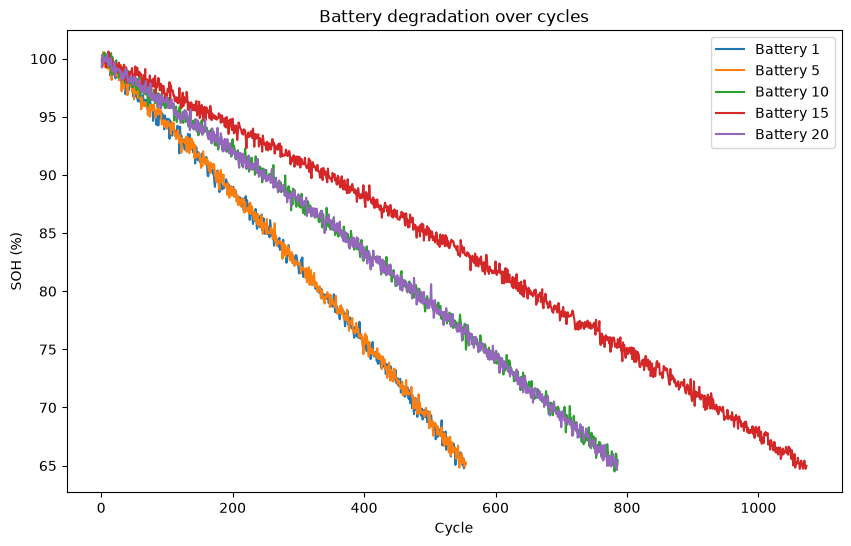

In [44]:
plt.figure(figsize=(10,6))
for b in [1, 5, 10, 15, 20]:
    sub = df[df["Battery_ID"] == b]
    plt.plot(sub["Cycle"], sub["SOH"], label="Battery " + str(b))
plt.xlabel("Cycle")
plt.ylabel("SOH (%)")
plt.title("Battery degradation over cycles")
plt.legend()
plt.show()

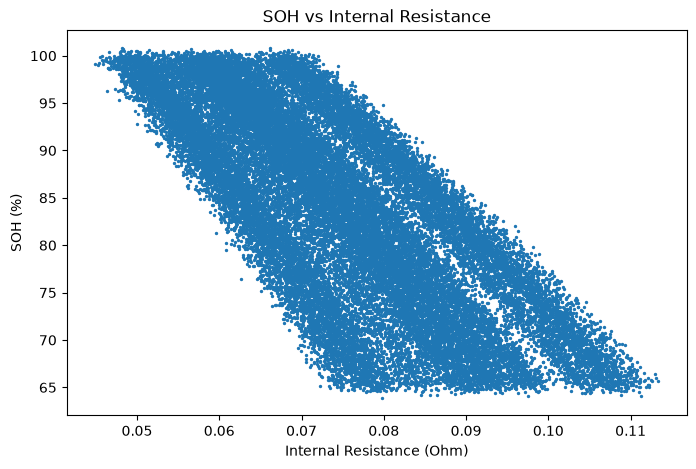

In [45]:
plt.figure(figsize=(8,5))
plt.scatter(df["Internal_Resistance_Ohm"], df["SOH"], s=2)
plt.xlabel("Internal Resistance (Ohm)")
plt.ylabel("SOH (%)")
plt.title("SOH vs Internal Resistance")
plt.show()

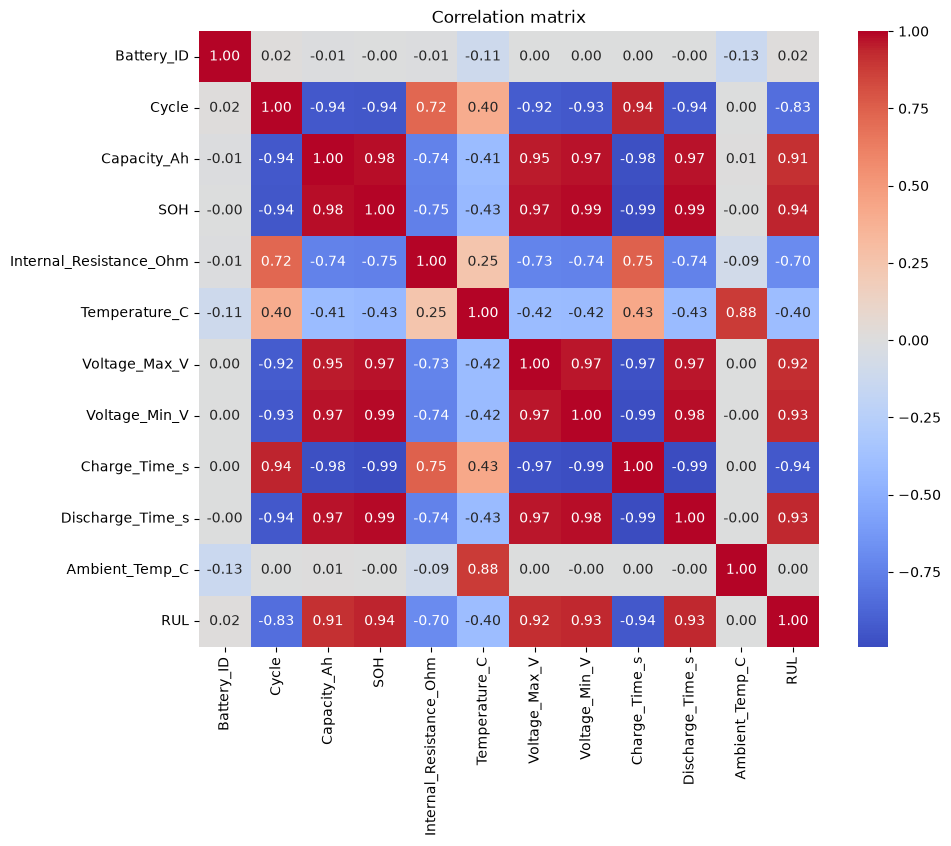

In [46]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

## 4. Preparing the data

We split by battery so that the test batteries are never seen during training.

In [47]:
features = ["Cycle", "Capacity_Ah", "Internal_Resistance_Ohm", "Temperature_C",
            "Voltage_Max_V", "Voltage_Min_V", "Charge_Time_s", "Discharge_Time_s", "Ambient_Temp_C"]
target = "SOH"

In [48]:
batteries = df["Battery_ID"].unique()
train_ids, test_ids = train_test_split(batteries, test_size=0.25, random_state=42)
train_df = df[df["Battery_ID"].isin(train_ids)]
test_df = df[df["Battery_ID"].isin(test_ids)]
print("Train batteries:", len(train_ids), "Test batteries:", len(test_ids))

Train batteries: 30 Test batteries: 10


In [49]:
X_train = train_df[features].values
y_train = train_df[target].values
X_test = test_df[features].values
y_test = test_df[target].values

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Evaluation function

In [51]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(name)
    print("MAE :", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R2  :", round(r2, 4))
    print()
    return [name, mae, rmse, r2]

## 6. Model 1 - Linear Regression

In [52]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
pred_lin = lin_model.predict(X_test_scaled)
res_lin = evaluate("Linear Regression", y_test, pred_lin)

Linear Regression
MAE : 0.653
RMSE: 0.817
R2  : 0.9935



## 7. Model 2 - Random Forest

In [53]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)
res_rf = evaluate("Random Forest", y_test, pred_rf)

Random Forest
MAE : 0.579
RMSE: 0.74
R2  : 0.9947



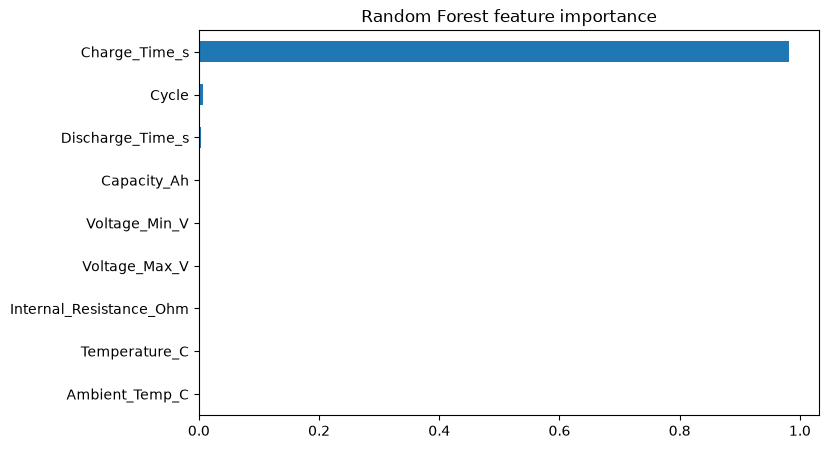

In [54]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(8,5))
importances.plot(kind="barh")
plt.title("Random Forest feature importance")
plt.show()

## 8. Data Preprocessing - Outlier Removal & Dimensionality Reduction

### 8.1 Outlier Removal with IsolationForest

In [55]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

In [56]:
iso = IsolationForest(contamination=0.01, random_state=42)
mask = iso.fit_predict(X_train_scaled) == 1
X_train_clean = X_train_scaled[mask]
y_train_clean = y_train[mask]
print(f"Removed {(~mask).sum()} outlier cycles out of {len(mask)}")
print(f"Training set size: {len(X_train_clean)} cycles remaining")

Removed 263 outlier cycles out of 26207
Training set size: 25944 cycles remaining


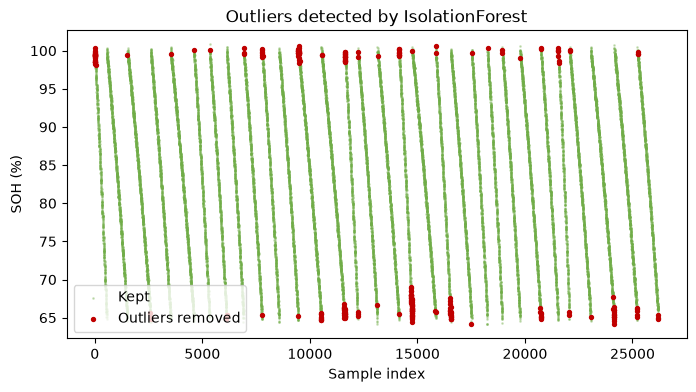

In [57]:
plt.figure(figsize=(8, 4))
plt.scatter(range(len(y_train)), y_train, s=1, alpha=0.3, label="Kept", color="#70ad47")
plt.scatter(np.where(~mask)[0], y_train[~mask], s=8, color="#c00000", label="Outliers removed")
plt.xlabel("Sample index")
plt.ylabel("SOH (%)")
plt.title("Outliers detected by IsolationForest")
plt.legend()
plt.show()

### 8.2 Dimensionality Reduction with PCA

In [58]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_clean)
X_test_pca  = pca.transform(X_test_scaled)
print(f"Features: {X_train_scaled.shape[1]} → {X_train_pca.shape[1]} principal components")
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Features: 9 → 3 principal components
Variance explained: 97.5%


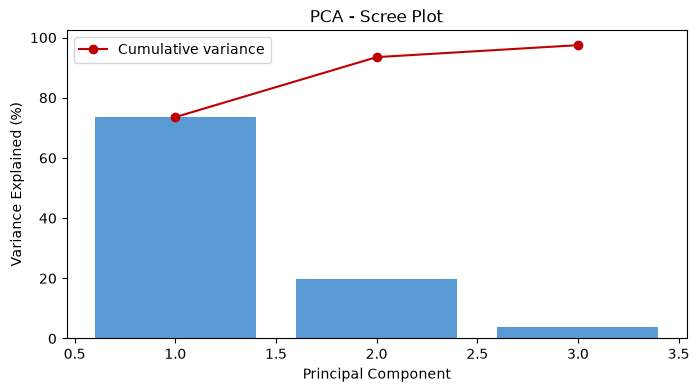

In [59]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_ * 100, color="#5b9bd5")
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_) * 100,
         color="#c00000", marker="o", label="Cumulative variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("PCA - Scree Plot")
plt.legend()
plt.show()

## 9. Model 3 - Neural Network

In [60]:
from tensorflow.keras.callbacks import TensorBoard
import os
import datetime

In [61]:
improved_model = Sequential()
improved_model.add(Dense(128, activation="relu", input_dim=X_train_pca.shape[1]))
improved_model.add(Dropout(0.4))
improved_model.add(Dense(64, activation="relu"))
improved_model.add(Dropout(0.4))
improved_model.add(Dense(32, activation="relu"))
improved_model.add(Dropout(0.2))
improved_model.add(Dense(1))
improved_model.compile(optimizer="adam", loss="mae")
improved_model.summary()

c:\Users\gabri\Desktop\Ml\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,881 (42.50 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 0 (0.00 B)

### TensorBoard

In [62]:
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir)

In [ ]:
weights = 1 / (y_train_clean + 1e-6)
weights = weights / weights.mean()

history_improved = improved_model.fit(
    X_train_pca, y_train_clean,
    epochs=200,
    batch_size=32,
    validation_data=(X_test_pca, y_test),
    callbacks=[tensorboard_callback],
    sample_weight=weights,
    verbose=1
)

Epoch 1/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 20.4359 - val_loss: 3.2070
Epoch 2/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 12.2329 - val_loss: 1.5792
Epoch 3/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 11.6672 - val_loss: 2.7926
Epoch 4/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 11.3145 - val_loss: 1.0029
Epoch 5/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 10.9450 - val_loss: 1.2237
Epoch 6/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 10.7631 - val_loss: 2.5156
Epoch 7/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 10.2389 - val_loss: 1.1158
Epoch 8/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.9282 - val_loss: 1.6694
Epoch 9/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.6118 - val_loss: 4.7633
Epoch 10/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.4162 - val_loss: 2.5334
Epoch 11/250
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.1530 - val_loss: 4.2743
Epoch 12/250
811/811 ━━━━━━━━━━━━━

In [64]:
%load_ext tensorboard
%tensorboard --logdir logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 13648), started 2:36:30 ago. (Use '!kill 13648' to kill it.)

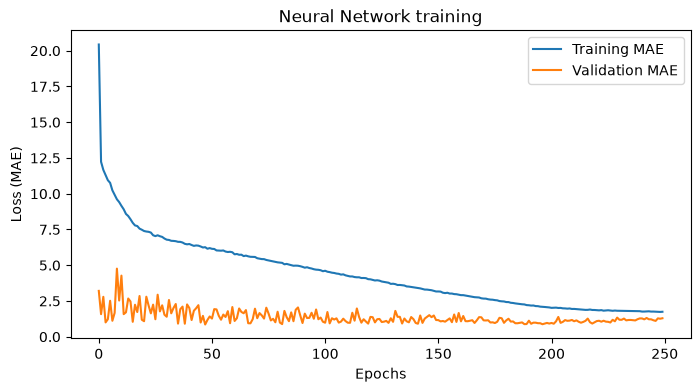

In [65]:
plt.figure(figsize=(8, 4))
plt.plot(history_improved.history["loss"], label="Training MAE")
plt.plot(history_improved.history["val_loss"], label="Validation MAE")
plt.xlabel("Epochs")
plt.ylabel("Loss (MAE)")
plt.title("Neural Network training")
plt.legend()
plt.show()

In [66]:
pred_nn = improved_model.predict(X_test_pca).flatten()
res_nn = evaluate("Neural Network", y_test, pred_nn)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Neural Network
MAE : 1.293
RMSE: 1.7
R2  : 0.9718



## 10. Additional KPIs

### 10.1 MAPE - Mean Absolute Percentage Error

In [67]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAPE (%) per model:")
print(f"  Linear Regression : {mape(y_test, pred_lin):.3f}%")
print(f"  Random Forest     : {mape(y_test, pred_rf):.3f}%")
print(f"  Neural Network    : {mape(y_test, pred_nn):.3f}%")

MAPE (%) per model:
  Linear Regression : 0.797%
  Random Forest     : 0.717%
  Neural Network    : 1.681%


### 10.2 Max Error - Worst Case Prediction

In [68]:
print("Max Error per model:")
print(f"  Linear Regression : {np.max(np.abs(y_test - pred_lin)):.3f}")
print(f"  Random Forest     : {np.max(np.abs(y_test - pred_rf)):.3f}")
print(f"  Neural Network    : {np.max(np.abs(y_test - pred_nn)):.3f}")

Max Error per model:
  Linear Regression : 3.513
  Random Forest     : 3.284
  Neural Network    : 6.187


### 10.3 Error by SOH Zone

In [69]:
zones = {
    "Healthy (SOH > 90%)": y_test > 90,
    "Degrading (75% < SOH <= 90%)": (y_test > 75) & (y_test <= 90),
    "End of life (SOH <= 75%)": y_test <= 75
}

print(f"{'Zone':<30} {'Samples':>8} {'MAE Lin':>10} {'MAE RF':>10} {'MAE NN':>10}")
print("-" * 72)
for zone_name, mask in zones.items():
    if mask.sum() == 0:
        continue
    mae_lin = mean_absolute_error(y_test[mask], pred_lin[mask])
    mae_rf  = mean_absolute_error(y_test[mask], pred_rf[mask])
    mae_nn  = mean_absolute_error(y_test[mask], pred_nn[mask])
    print(f"{zone_name:<30} {mask.sum():>8} {mae_lin:>10.3f} {mae_rf:>10.3f} {mae_nn:>10.3f}")

Zone                            Samples    MAE Lin     MAE RF     MAE NN
------------------------------------------------------------------------
Healthy (SOH > 90%)                2650      0.670      0.474      0.947
Degrading (75% < SOH <= 90%)       3571      0.625      0.612      0.792
End of life (SOH <= 75%)           2179      0.678      0.654      2.535


### 10.4 Residuals Distribution

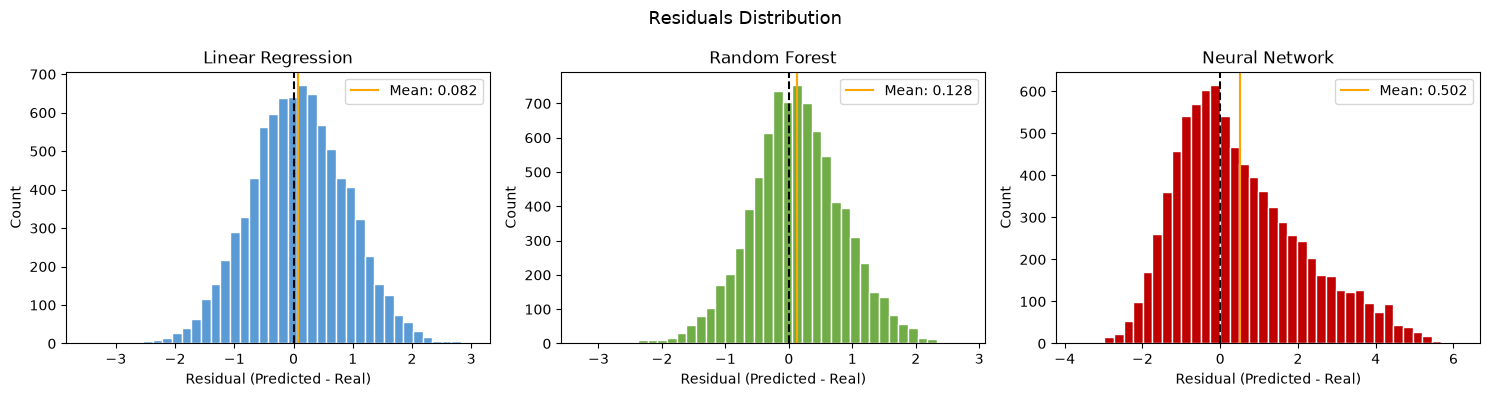

In [70]:
residuals_lin = pred_lin - y_test
residuals_rf  = pred_rf  - y_test
residuals_nn  = pred_nn  - y_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, residuals, name, color in zip(
    axes,
    [residuals_lin, residuals_rf, residuals_nn],
    ["Linear Regression", "Random Forest", "Neural Network"],
    ["#5b9bd5", "#70ad47", "#c00000"]
):
    ax.hist(residuals, bins=40, color=color, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1.5, linestyle="--")
    ax.axvline(np.mean(residuals), color="orange", linewidth=1.5, linestyle="-", label=f"Mean: {np.mean(residuals):.3f}")
    ax.set_xlabel("Residual (Predicted - Real)")
    ax.set_ylabel("Count")
    ax.set_title(name)
    ax.legend()

plt.suptitle("Residuals Distribution", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Comparing the models

In [71]:
results = pd.DataFrame([res_lin, res_rf, res_nn], columns=["Model", "MAE", "RMSE", "R2"])
results

,Model,MAE,RMSE,R2
0,Linear Regression,0.652691,0.816842,0.993485
1,Random Forest,0.579222,0.739841,0.994655
2,Neural Network,1.293127,1.699652,0.971792


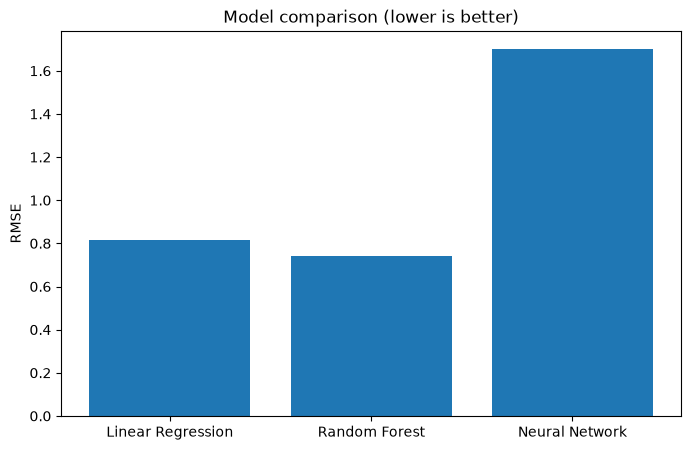

In [72]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.ylabel("RMSE")
plt.title("Model comparison (lower is better)")
plt.show()

## 12. Predicted vs Real SOH

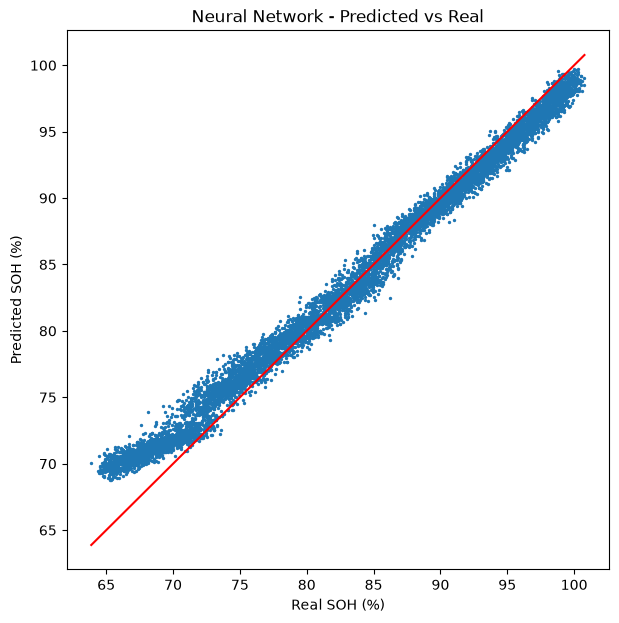

In [73]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred_nn, s=2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Real SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.title("Neural Network - Predicted vs Real")
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


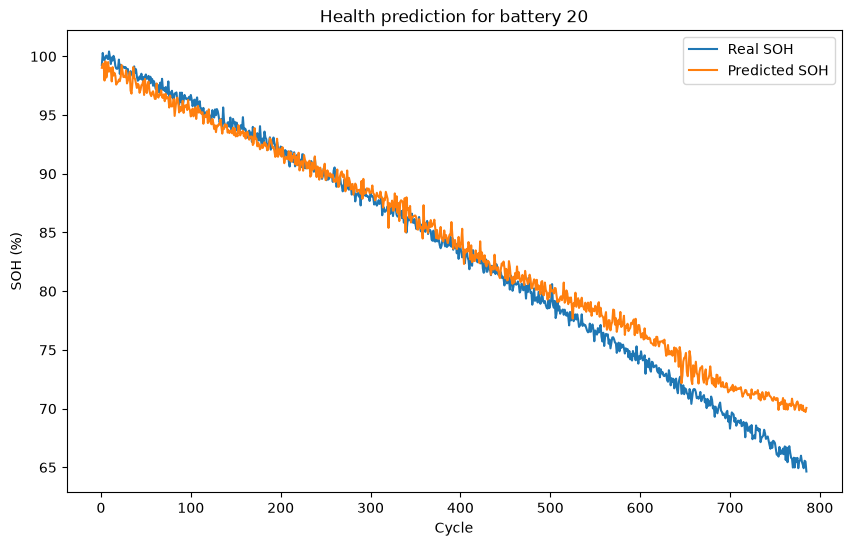

In [74]:
one_id = test_ids[0]
one = test_df[test_df["Battery_ID"] == one_id].sort_values("Cycle")
one_scaled = scaler.transform(one[features].values)
one_pca    = pca.transform(one_scaled)
one_pred   = improved_model.predict(one_pca).flatten()
plt.figure(figsize=(10,6))
plt.plot(one["Cycle"], one["SOH"], label="Real SOH")
plt.plot(one["Cycle"], one_pred, label="Predicted SOH")
plt.xlabel("Cycle")
plt.ylabel("SOH (%)")
plt.title("Health prediction for battery " + str(one_id))
plt.legend()
plt.show()

## 13. Conclusion

The Neural Network pipeline combines three techniques from the course: IsolationForest (Session 5) to remove noisy training cycles, PCA (Session 5) to reduce the 9 features into their most informative components, and a deep network (Session 1) with strong Dropout regularization. Sample weighting gives higher importance to End-of-Life predictions (low SOH), reducing the systematic plateau effect. The MAPE, Max Error, error by SOH zone and residuals distribution provide a complete evaluation across all degradation stages. Internal resistance and capacity remain the most important features for predicting battery health.